In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cell-to-cell correlation (heatmap)

Infile: results/matrix/K562.s4U_0uM_180min.read_based.csv


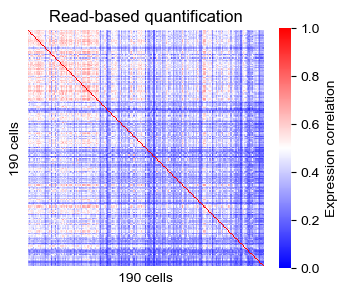

Infile: results/matrix/K562.s4U_0uM_180min.umi_based.csv


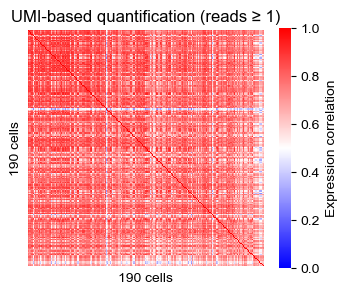

Infile: results/matrix/K562.s4U_0uM_180min.umi_based.mrUMI.csv


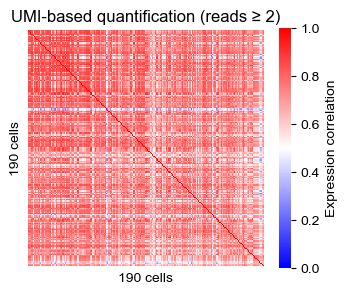

Infile: results/matrix/K562.s4U_50uM_180min.read_based.csv


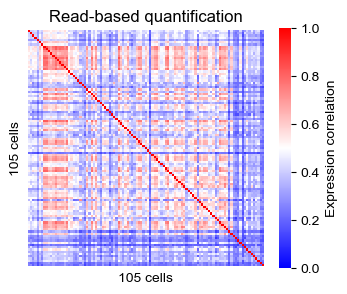

Infile: results/matrix/K562.s4U_50uM_180min.umi_based.csv


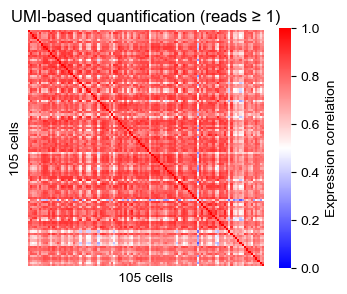

Infile: results/matrix/K562.s4U_50uM_180min.umi_based.mrUMI.csv


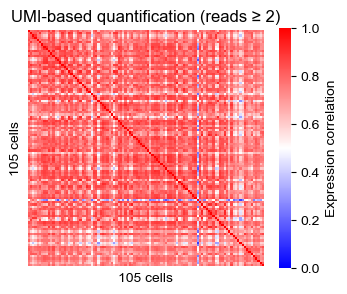

Infile: results/matrix/mESC.s4U_0uM_180min.read_based.csv


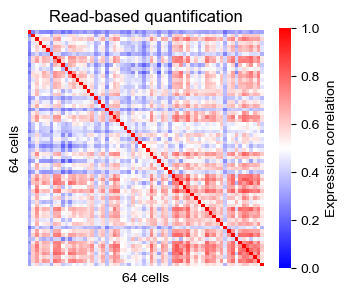

Infile: results/matrix/mESC.s4U_0uM_180min.umi_based.csv


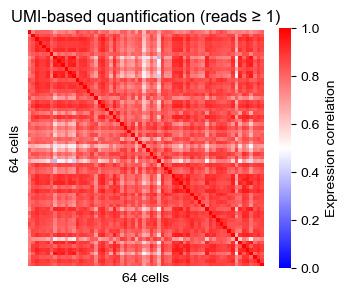

Infile: results/matrix/mESC.s4U_0uM_180min.umi_based.mrUMI.csv


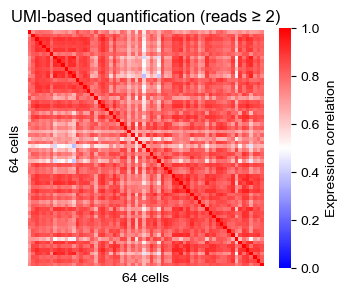

Infile: results/matrix/mESC.s4U_400uM_180min.read_based.csv


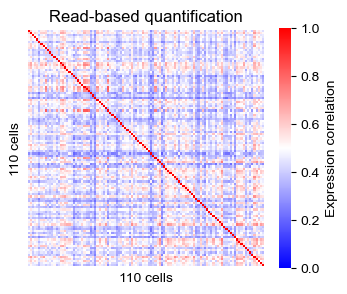

Infile: results/matrix/mESC.s4U_400uM_180min.umi_based.csv


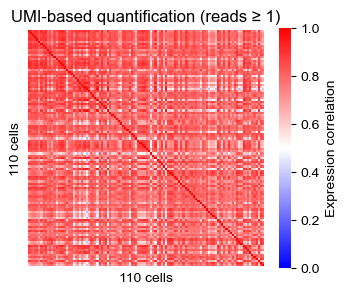

Infile: results/matrix/mESC.s4U_400uM_180min.umi_based.mrUMI.csv


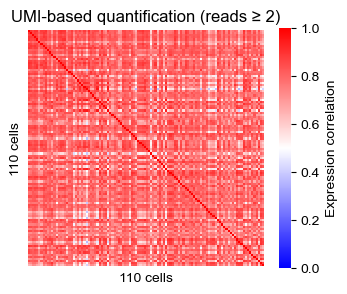

In [8]:
def plot_heatmap(infile, outfile, title):
    m = pd.read_csv(infile, index_col=0)
    corr = m.corr()
    plt.figure(figsize=(3.6, 3))
    plt.title(title)
    sns.heatmap(corr, cmap="bwr", vmin=0, vmax=1, square=True, cbar_kws={"label": "Expression correlation"})
    plt.xticks([])
    plt.yticks([])
    plt.xlabel("%d cells" % len(corr))
    plt.ylabel("%d cells" % len(corr))
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()
    
for name in ["K562.s4U_0uM_180min", "K562.s4U_50uM_180min", "mESC.s4U_0uM_180min", "mESC.s4U_400uM_180min"]:
    for group in ["read_based", "umi_based", "umi_based.mrUMI"]:
        infile = "results/matrix/%s.%s.csv" % (name, group)
        outfile = "figures/correlation.heatmap.%s.%s.pdf" % (name, group)
        print("Infile:", infile)
        if group == "read_based":
            title = "Read-based quantification"
        elif group == "umi_based":
            title = "UMI-based quantification (reads ≥ 1)"
        elif group == "umi_based.mrUMI":
            title = "UMI-based quantification (reads ≥ 2)"

        plot_heatmap(infile, outfile, title)

# 2. Cell-to-cell correlation density (bar)

Infile: results/matrix/K562.s4U_0uM_180min.read_based.csv


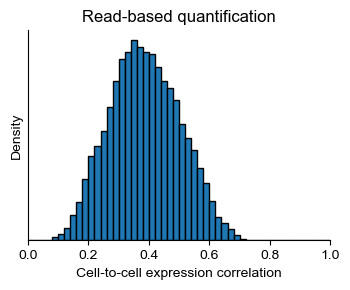

Infile: results/matrix/K562.s4U_0uM_180min.umi_based.csv


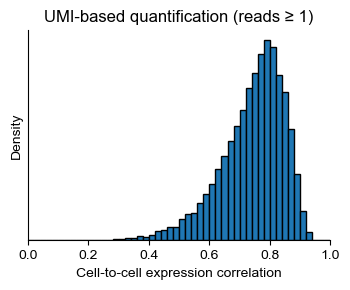

Infile: results/matrix/K562.s4U_0uM_180min.umi_based.mrUMI.csv


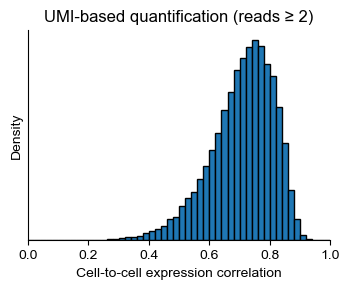

Infile: results/matrix/K562.s4U_50uM_180min.read_based.csv


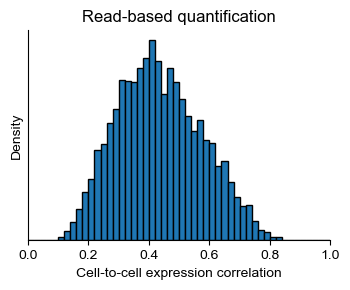

Infile: results/matrix/K562.s4U_50uM_180min.umi_based.csv


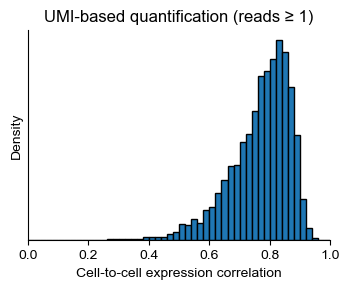

Infile: results/matrix/K562.s4U_50uM_180min.umi_based.mrUMI.csv


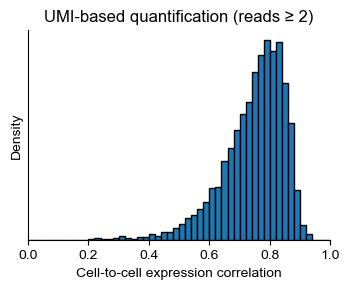

Infile: results/matrix/mESC.s4U_0uM_180min.read_based.csv


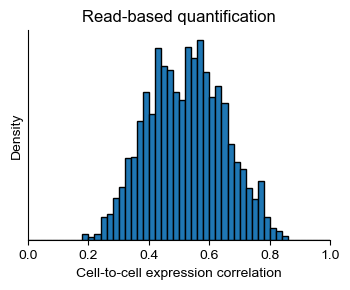

Infile: results/matrix/mESC.s4U_0uM_180min.umi_based.csv


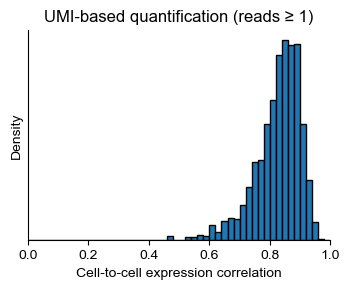

Infile: results/matrix/mESC.s4U_0uM_180min.umi_based.mrUMI.csv


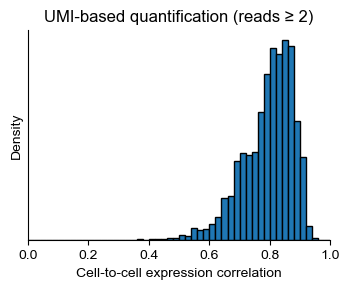

Infile: results/matrix/mESC.s4U_400uM_180min.read_based.csv


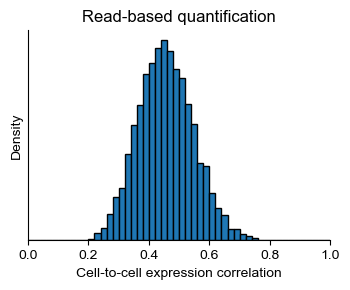

Infile: results/matrix/mESC.s4U_400uM_180min.umi_based.csv


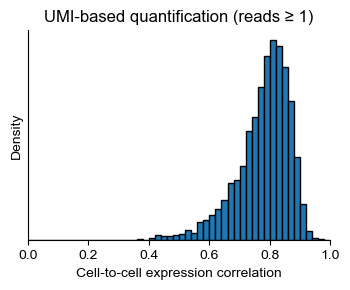

Infile: results/matrix/mESC.s4U_400uM_180min.umi_based.mrUMI.csv


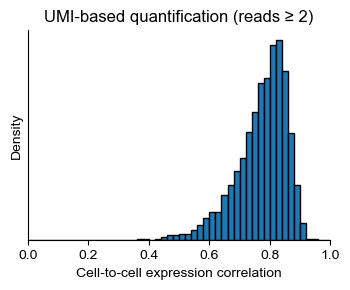

In [9]:
def plot_correlation_density(path, outfile, title):
    m = pd.read_csv(path, index_col=0)
    corr = m.corr()
    vs = []
    for i in range(len(corr)):
        for j in range(len(corr)):
            if i < j:
                vs.append(corr.values[i][j])
    vs = np.array(vs)
    
    plt.figure(figsize=(3.6, 3))
    plt.title(title)
    plt.hist(vs, edgecolor="black", range=(0, 1), bins=50, color="C0", density=True)
    plt.xlim(0, 1)
    plt.xlabel("Cell-to-cell expression correlation")
    plt.ylabel("Density")        
    plt.yticks([])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()
    

for name in ["K562.s4U_0uM_180min", "K562.s4U_50uM_180min", "mESC.s4U_0uM_180min", "mESC.s4U_400uM_180min"]:
    for group in ["read_based", "umi_based", "umi_based.mrUMI"]:
        infile = "results/matrix/%s.%s.csv" % (name, group)
        outfile = "figures/correlation_density.bar.%s.%s.pdf" % (name, group)
        print("Infile:", infile)

        if group == "read_based":
            title = "Read-based quantification"
        elif group == "umi_based":
            title = "UMI-based quantification (reads ≥ 1)"
        elif group == "umi_based.mrUMI":
            title = "UMI-based quantification (reads ≥ 2)"

        plot_correlation_density(infile, outfile, title)